In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from arch import arch_model

In [2]:
df = pd.read_csv("../data/processed/market_data_processed.csv")
df.head()

,Date,SP500_Close,VIX_Close,SP500_LogReturn
0,2010-01-05,1136.520020,19.350000,0.003111
1,2010-01-06,1137.140015,19.160000,0.000545
2,2010-01-07,1141.689941,19.059999,0.003993
3,2010-01-08,1144.979980,18.129999,0.002878
4,2010-01-11,1146.979980,17.549999,0.001745


In [3]:
df["Date"] = pd.to_datetime(df["Date"])
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4058 entries, 0 to 4057
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Date             4058 non-null   datetime64[us]
 1   SP500_Close      4058 non-null   float64       
 2   VIX_Close        4058 non-null   float64       
 3   SP500_LogReturn  4058 non-null   float64       
dtypes: datetime64[us](1), float64(3)
memory usage: 126.9 KB


In [4]:
returns = df["SP500_LogReturn"].dropna().values
returns

array([ 0.00311083,  0.00054537,  0.00399322, ..., -0.00282612,
        0.00691576, -0.01043996], shape=(4058,))

# Train test split

In [5]:
split = int(len(returns) * 0.8)

train = returns[:split]
test = returns[split:]

In [6]:
type(test), type(train)

(numpy.ndarray, numpy.ndarray)

In [ ]:
# making train and test dataframes because iloc doesn't work with array
train_df = pd.DataFrame(train, columns=["SP500_LogReturn"])
test_df = pd.DataFrame(test, columns=["SP500_LogReturn"])

In [8]:
type(train_df), type(test_df)

(pandas.DataFrame, pandas.DataFrame)

# Rolling 1-Step Ahead GARCH Forecast

In [9]:
garch_forecasts = []
realized_variance = []

rolling_returns = train_df.copy()

for i in range(len(test_df)):

    model = arch_model(rolling_returns * 100, vol="Garch", p=1, q=1)
    res = model.fit(disp="off")

    forecast = res.forecast(horizon=1)
    var_pred = forecast.variance.iloc[-1, 0] / (100**2)

    garch_forecasts.append(var_pred)

    realized_variance.append(test_df.iloc[i]**2)

    rolling_returns = pd.concat([rolling_returns, test_df.iloc[i:i+1]])

# Historical Volatility Forecast

In [10]:
hv_forecasts = []

rolling_returns = train_df.copy()

for i in range(len(test_df)):

    hv = rolling_returns.rolling(20).std().iloc[-1]
    hv_forecasts.append(hv**2)

    rolling_returns = pd.concat([rolling_returns, test_df.iloc[i:i+1]])

# Vix based forecast

In [11]:
vix_test = df["VIX_Close"].iloc[split:split+len(test)]

vix_variance = ((vix_test / 100) / np.sqrt(252))**2

# Convert to Arrays

In [12]:
garch_forecasts = np.array(garch_forecasts)
hv_forecasts = np.array(hv_forecasts)
realized_variance = np.array(realized_variance)
vix_variance = vix_variance.values

In [14]:
garch_forecasts

array([1.43494159e-04, 1.16755054e-04, 1.45497304e-04, 1.19401434e-04,
       2.60395794e-04, 2.09950743e-04, 1.70397687e-04, 2.03340984e-04,
       2.07202213e-04, 1.68816248e-04, 1.45431417e-04, 1.30836655e-04,
       1.39965127e-04, 1.22050724e-04, 1.08775255e-04, 2.13119407e-04,
       1.98486007e-04, 1.78379216e-04, 1.44972765e-04, 1.54031292e-04,
       1.68363570e-04, 1.41731396e-04, 1.20190029e-04, 1.28907473e-04,
       1.55436757e-04, 1.28831884e-04, 1.09906357e-04, 9.89837423e-05,
       1.10354703e-04, 1.77365236e-04, 1.44649266e-04, 1.25252915e-04,
       1.28971311e-04, 1.07179521e-04, 9.05004363e-05, 7.68267981e-05,
       1.13562405e-04, 1.06602862e-04, 1.46483529e-04, 1.41835895e-04,
       1.16589826e-04, 9.63526946e-05, 9.87362053e-05, 8.25404859e-05,
       1.03612858e-04, 1.19964973e-04, 1.15519875e-04, 1.29687719e-04,
       1.29142757e-04, 1.14823646e-04, 1.20753419e-04, 1.25096232e-04,
       1.19699940e-04, 9.90378181e-05, 1.02495542e-04, 8.52290420e-05,
      

# Evaluation matrics

In [13]:
def mse(pred, true):
    return np.mean((pred - true)**2)

mse_garch = mse(garch_forecasts, realized_variance)
mse_hv = mse(hv_forecasts, realized_variance)
mse_vix = mse(vix_variance, realized_variance)

mse_garch, mse_hv, mse_vix

(np.float64(1.4312141915536385e-07),
 np.float64(1.2576358883816044e-07),
 np.float64(1.3024790005692633e-07))

# Qlike Loss

In [15]:
def qlike(pred, true):
    ratio = true / pred
    return np.mean(ratio - np.log(ratio) - 1)

qlike_garch = qlike(garch_forecasts, realized_variance)
qlike_hv = qlike(hv_forecasts, realized_variance)
qlike_vix = qlike(vix_variance, realized_variance)

qlike_garch, qlike_hv, qlike_vix

(np.float64(2.073630806816222),
 np.float64(1.7629912844196127),
 np.float64(1.9374302614911023))

# Plot Forecast vs Realized Variance

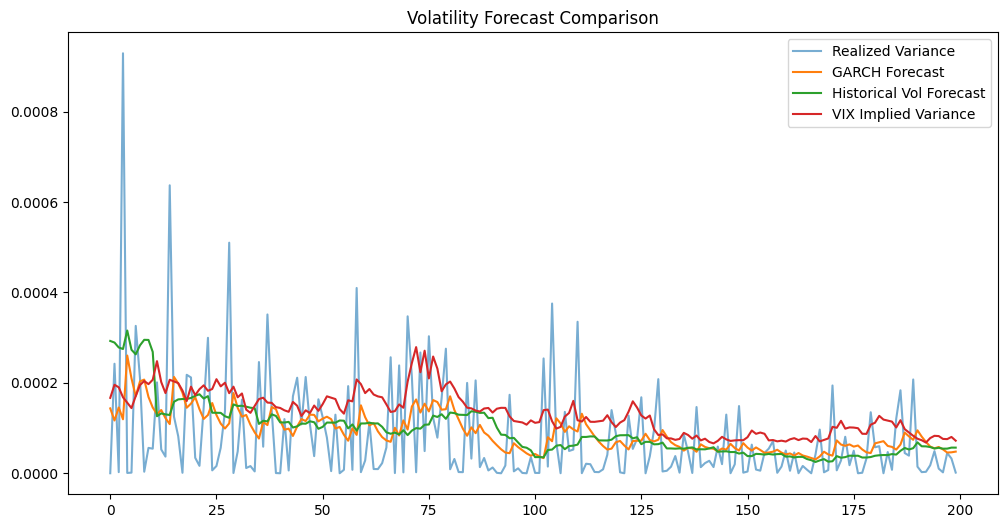

In [16]:
plt.figure(figsize=(12,6))

plt.plot(realized_variance[:200], label="Realized Variance", alpha=0.6)
plt.plot(garch_forecasts[:200], label="GARCH Forecast")
plt.plot(hv_forecasts[:200], label="Historical Vol Forecast")
plt.plot(vix_variance[:200], label="VIX Implied Variance")

plt.legend()
plt.title("Volatility Forecast Comparison")
plt.show()